In [128]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.metrics import accuracy_score, roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix

# Generate dataset

In [118]:
X, y = make_classification( n_samples=2502,
                            random_state=259202,
                            n_features=2,
                            n_informative=2,
                            n_redundant=0,
                            n_repeated=0,
                            class_sep=2)
Xm, ym = make_moons(n_samples=2502, random_state=259202, noise=0.1)
Xb ,yb = make_blobs(n_samples=2502, random_state=259202, n_features=2, centers=5, cluster_std=0.8)

In [119]:
X.shape, y.shape, Xm.shape, ym.shape, Xb.shape, yb.shape

((2502, 2), (2502,), (2502, 2), (2502,), (2502, 2), (2502,))

In [120]:
print(set(yb))
yb = np.where(yb < 3, 0, 1)
print(set(yb))

{0, 1, 2, 3, 4}
{0, 1}


In [121]:
def plot_data(X, y, title=""):
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
    plt.title(title)
    plt.show()

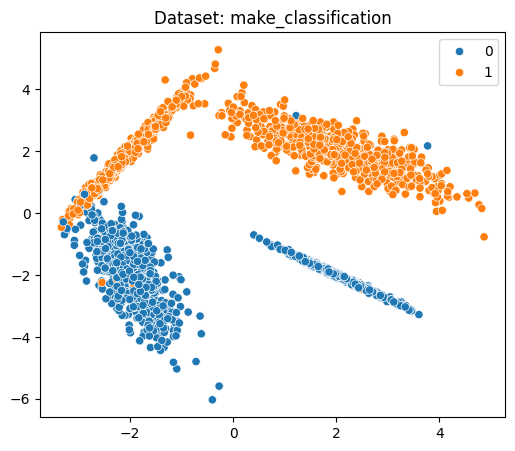

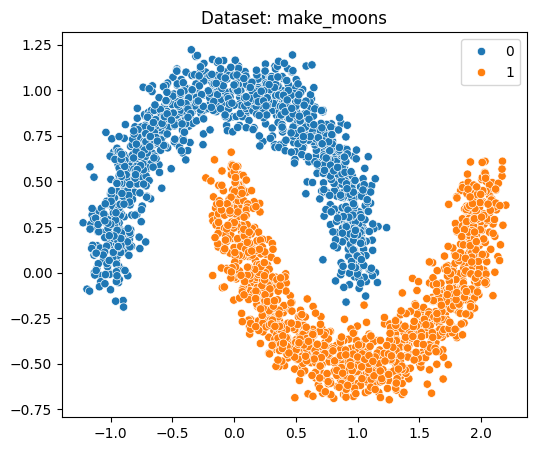

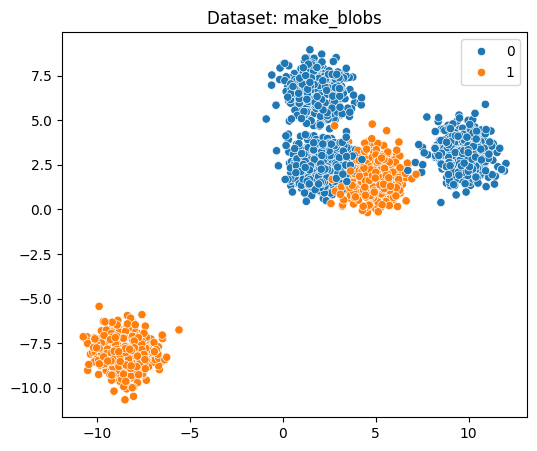

In [122]:
plot_data(X,y,"Dataset: make_classification")
plot_data(Xm,ym,"Dataset: make_moons")
plot_data(Xb,yb,"Dataset: make_blobs")

In [123]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=295202)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, random_state=295202)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(Xb, yb, random_state=295202)

In [124]:
def plot_decision_boundary(X, y, model, title=""):
    h = 0.02
    x_min, x_max = X[:,0].min(), X[:,0].max()
    y_min, y_max = X[:,1].min(), X[:,1].max()
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    pts = np.c_[xx.ravel(), yy.ravel()]
    
    Z = model.predict(pts)
    
    Z = Z.reshape(xx.shape)
    
    # decition boundary
    plt.contourf(xx, yy, Z, alpha=0.3)
    
    # decision line
    plt.contour(xx, yy, Z, colors='k', linewidths=1)
    
    scatter = plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
    
    plt.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
    plt.title(title)
    plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.show()

In [125]:
results = []

# Implemented RandomForestClassifier

In [126]:
class TreeNode:
    """Node of a decision tree"""
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None,*, value=None, distribution=None):
        self.feature_idx = feature_idx # index of the feature to split on
        self.threshold = threshold # threshold value to split on
        self.left = left # left child node
        self.right = right # right child node
        self.value = value # class label if leaf node, the * is forcing the use of keyword arguments for value
        self.distribution = distribution
        
    def is_leaf(self):
        return self.value is not None

In [158]:
class DecisionTree:
    """Decision Tree Classifier with Gini"""
    def __init__(self, max_depth=None, min_samples_split=2, n_features=None):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.root = None
    
    def fit(self, X, y):
        self.n_classes_ = len(np.unique(y))
        self.n_features_ = X.shape[1]
        self.root = self._grow_tree(X, y, depth=0)
        return self
        
    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        
        # stopping criteria
        if (self.max_depth is not None and depth >= self.max_depth) or n_labels == 1 or n_samples < self.min_samples_split:
            leaf_value = self._most_common_label(y)
            
            hist = np.bincount(y, minlength=max(y)+1)
            distribution = hist / len(y)
        
            return TreeNode(value=leaf_value, distribution=distribution)
        
        # random
        feat_idxs = np.random.choice(n_features, self.n_features if self.n_features else n_features, replace=False)
        best_feature, best_thresh = self._best_split(X, y, feat_idxs)
        
        # handle edge case - no split found
        if best_feature is None or best_thresh is None:
            leaf_value = self._most_common_label(y)
            
            hist = np.bincount(y, minlength=max(y)+1)
            distribution = hist / len(y)
            
            return TreeNode(value=leaf_value, distribution=distribution)
        
        # create child nodes
        left_idxs, right_idxs = self._split(X[:, best_feature] ,best_thresh)
        left = self._grow_tree(X[left_idxs, :], y[left_idxs], depth+1)
        right = self._grow_tree(X[right_idxs, :], y[right_idxs], depth+1)
        
        return TreeNode(best_feature, best_thresh, left, right)
        
    def _best_split(self, X, y, feat_idxs):
        best_gini = 1.0
        split_idx, split_thr = None, None
        
        for feat_idx in feat_idxs:
            X_column = X[:, feat_idx]
            values = np.unique(X_column)
            if len(values) > 50: # for too many unique values, we can use a threshold
                thresholds = np.linspace(values.min(), values.max(), 50)
            else:
                thresholds = values
            
            for thr in thresholds:
                left_idxs, right_idxs = self._split(X_column, thr)
                if len(left_idxs) == 0 or len(right_idxs) == 0:
                    continue
                gini = self._gini_index(y[left_idxs], y[right_idxs])
                if gini < best_gini:
                    best_gini = gini
                    split_idx = feat_idx
                    split_thr = thr
                    
        return split_idx, split_thr

    def _gini_index(self, y_left, y_right):
        def gini(y):
            m = len(y)
            if m == 0:
                return 0
            counts = np.bincount(y, minlength=self.n_classes_)
            p = counts / m
            return 1 - np.sum(p ** 2)
        m = len(y_left) + len(y_right)
        return (len(y_left) / m) * gini(y_left) + (len(y_right) / m) * gini(y_right)
        
    def _split(self, X_column, split_threshold):
        left_idxs = np.argwhere(X_column <= split_threshold).flatten()
        right_idxs = np.argwhere(X_column > split_threshold).flatten()
        return left_idxs, right_idxs
        
        
    def _most_common_label(self, y):
        counter = Counter(y)
        value = counter.most_common(1)[0][0]
        return value
    
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])
    
    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value
        
        if x[node.feature_idx] <= node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)
    
    def predict_proba(self, X):
        n_samples = X.shape[0]
        proba = np.zeros((n_samples, self.n_classes_))
        for i, x in enumerate(X):
            node = self.root
            while not node.is_leaf():
                if x[node.feature_idx] <= node.threshold:
                    node = node.left
                else:
                    node = node.right
            proba[i, :len(node.distribution)] = node.distribution
        return proba

In [159]:
class RandomForest:
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=2, n_features=None):
        self.n_trees = n_trees # number of trees in the forest
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features # number of features to consider for each split, if None, will use sqrt(n_features)
        self.trees = [] # list to hold the individual trees
        self.oob_indices = []
        
    def fit(self, X, y, max_oob_increase=3):
        self.trees = []
        self.oob_scores = [] # list to hold out-of-bag scores
        self.oob_indices = []
        self.n_classes_ = len(np.unique(y))
        
        n_samples = X.shape[0]
        last_oob = 1.0 # initial OOB score
        oob_increase = 0
        
        for _ in range(1, self.n_trees + 1):
            idxs = np.random.choice(n_samples, n_samples, replace=True) # bagging
            oob_idx = set(np.setdiff1d(np.arange(n_samples), np.unique(idxs)))
            X_boot, y_boot = X[idxs], y[idxs]
            tree = DecisionTree(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                n_features=self.n_features if self.n_features else int(np.sqrt(X.shape[1]))
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)
            self.oob_indices.append(oob_idx)
            
            # OOB prediction
            oob_mask = np.ones(n_samples, dtype=bool) # OOB mask - data not included in the bootstrap sample
            oob_mask[idxs] = False
            if np.any(oob_mask):
                oob_pred = self._oob_predict(X)
                valid = oob_mask & (oob_pred != -1)
                if np.any(valid):
                    oob_acc = np.mean(oob_pred[valid] == y[valid])
                    self.oob_scores.append(oob_acc)
                    if oob_acc < last_oob:
                        oob_increase += 1
                    else:
                        oob_increase = 0
                    last_oob = oob_acc
                    if oob_increase >= max_oob_increase:
                        break

    def _oob_predict(self, X):
        n_samples = X.shape[0]
        votes = [[] for _ in range(n_samples)]
        for tree, oob_idx in zip(self.trees, self.oob_indices):
            mask = np.array([i in oob_idx for i in range(n_samples)])
            if not np.any(mask):
                continue
            pred = tree.predict(X[mask])
            for idx, p in zip(np.where(mask)[0], pred):
                votes[idx].append(p)
        maj = np.full(n_samples, -1, dtype=int)
        for i, v in enumerate(votes):
            if v:
                maj[i] = np.bincount(v, minlength=self.n_classes_).argmax()
        return maj
            

    def predict(self, X):
        tree_preds = np.array([tree.predict(X) for tree in self.trees])
        # majority vote
        maj = []
        for row in tree_preds.T:
            counts = np.bincount(row, minlength=self.n_classes_)
            maj.append(np.argmax(counts))
        return np.array(maj)
        
        
    def predict_proba(self, X):
        proba = np.mean([tree.predict_proba(X) for tree in self.trees], axis=0)
        return proba

In [160]:
rf = RandomForest(n_trees=100, max_depth=10, n_features=int(np.sqrt(X_train.shape[1])))
rf.fit(X_train, y_train, max_oob_increase=3)
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("RandomForest (Gini, OOB):", acc, "OOB:", np.mean(rf.oob_scores))

RandomForest (Gini, OOB): 0.9952076677316294 OOB: 0.9817011957148227


In [133]:
datasets = {
    'classification': (X_train, y_train, X_test, y_test),
    'moons': (Xm_train, ym_train, Xm_test, ym_test),
    'blobs': (Xb_train, yb_train, Xb_test, yb_test)
}

for ds_name, (X_tr, y_tr, X_te, y_te) in datasets.items():
    
    depths = [None,
              X_tr.shape[1] # number of features
              ] + ([5] # number of clusters
                   if ds_name == 'blobs' else [])
    
    for depth in set(depths):
        rf = RandomForest(
            n_trees=100,
            max_depth=depth,
            n_features=int(np.sqrt(X_tr.shape[1]))
        )
        rf.fit(X_tr, y_tr, max_oob_increase=3)
        y_pr = rf.predict(X_te)
        y_sc = rf.predict_proba(X_te)
        acc = accuracy_score(y_te, y_pr)
        results.append({
            'type': 'implemented',
            'dataset': ds_name,
            'accuracy': acc,
            'depth': depth,
            'model': rf,
            'y_pred': y_pr,
            'y_score': y_sc,
            'y_true': y_te
        })

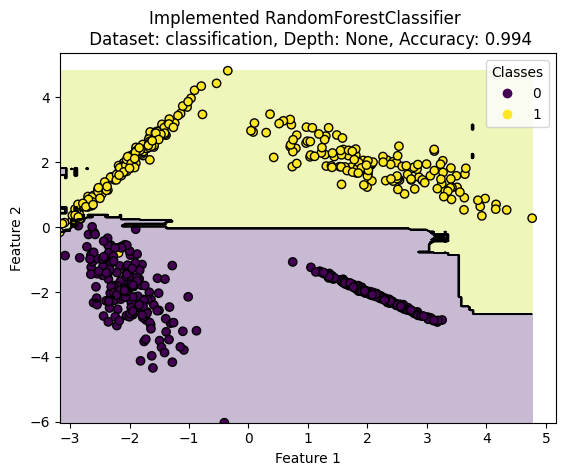

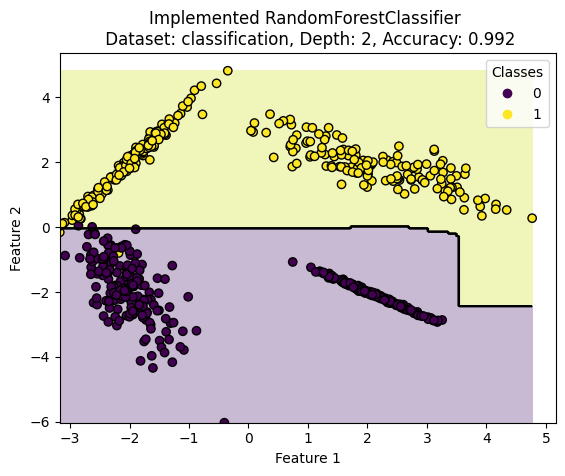

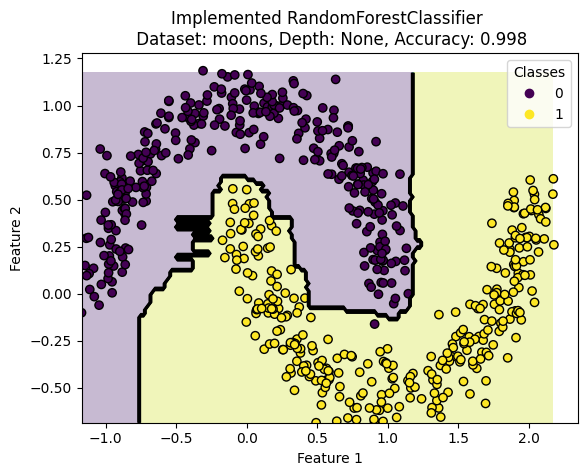

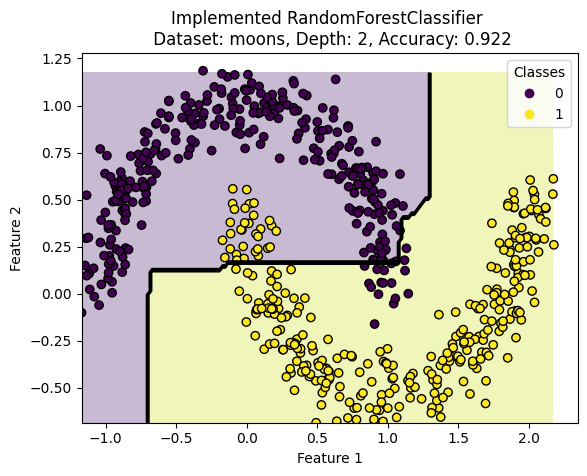

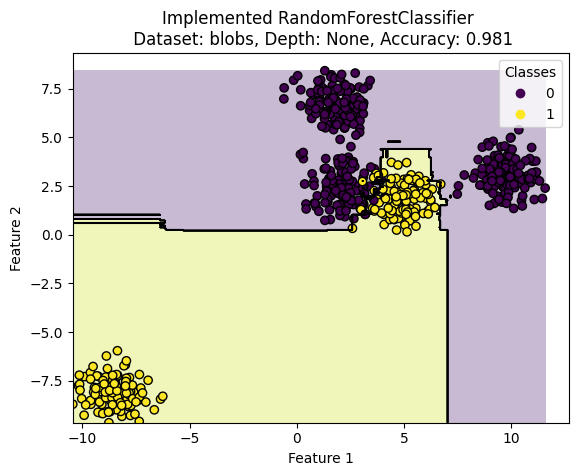

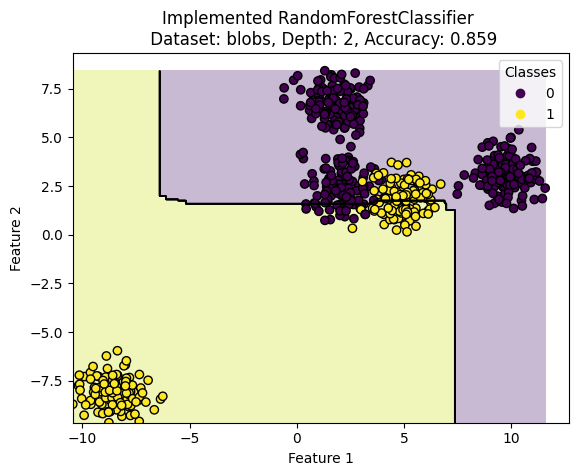

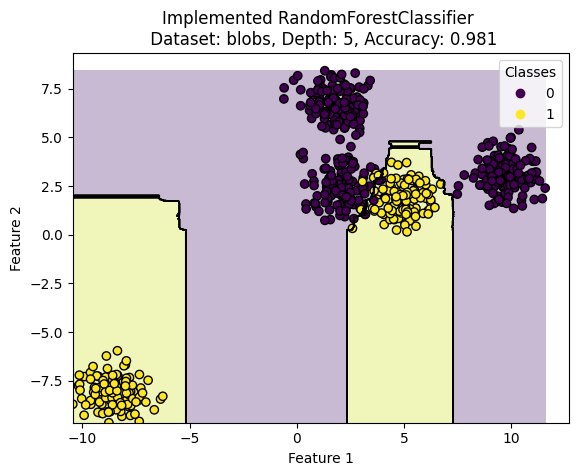

In [134]:
for res in results:
    ds_name = res['dataset']
    depth = res['depth']
    model = res['model']
    acc = res['accuracy']
    _, _, X_te, y_te = datasets[ds_name]
    title = f"Implemented RandomForestClassifier \n Dataset: {ds_name}, Depth: {depth}, Accuracy: {acc:.3f}"
    plot_decision_boundary(X_te, y_te, model, title=title)

# Sklearn RandomForestClassifier

In [136]:
def train_sklearn_random_forest(X_tr, y_tr, X_te, y_te, depth):
    clf = RandomForestClassifier(   criterion='gini',
                                    max_depth=depth, 
                                    random_state=259202)
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    y_score = clf.predict_proba(X_te)
    acc = accuracy_score(y_te, y_pred)
    
    return clf, acc, y_pred, y_score

In [137]:
for ds_name, (X_tr, y_tr, X_te, y_te) in datasets.items():
    
    depths = [None,
              X_tr.shape[1] # number of features
              ] + ([5] # number of clusters
                   if ds_name == 'blobs' else [])
    
    for depth in set(depths):
        model, acc, y_pr, y_sc = train_sklearn_random_forest(X_tr, y_tr, X_te, y_te, depth)
        results.append({
            'type': 'sklearn',
            'dataset': ds_name,
            'accuracy': acc,
            'depth': depth,
            'model': model,
            'y_pred': y_pr,
            'y_score': y_sc,
            'y_true': y_te
        })

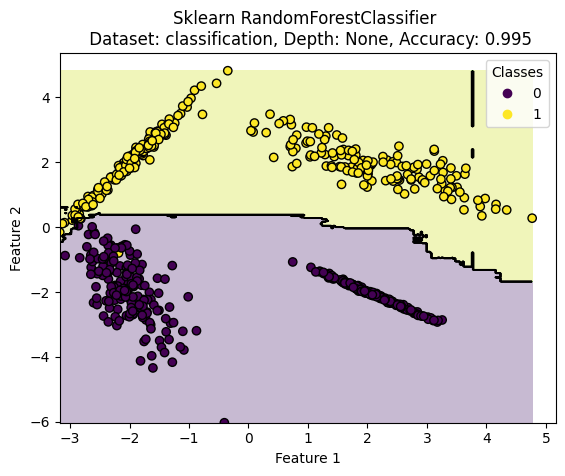

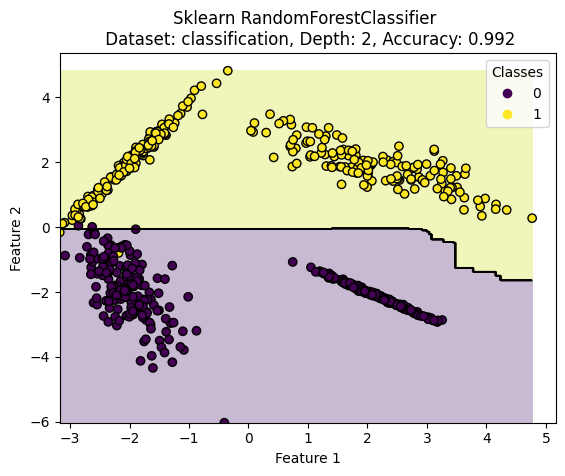

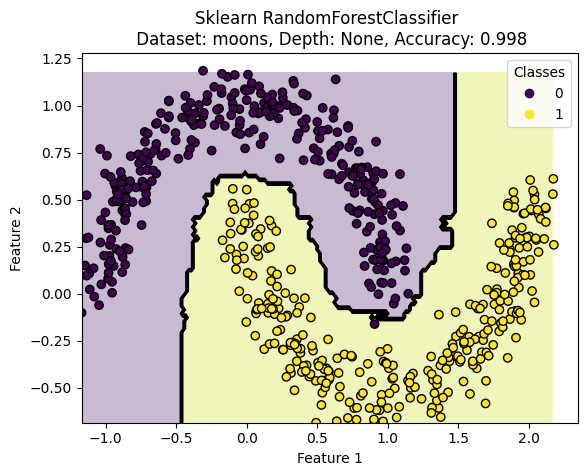

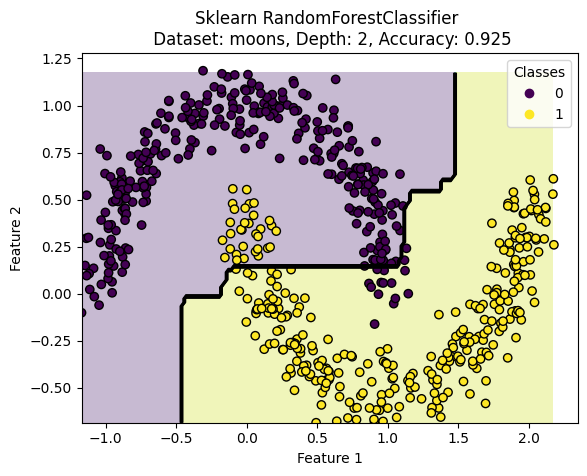

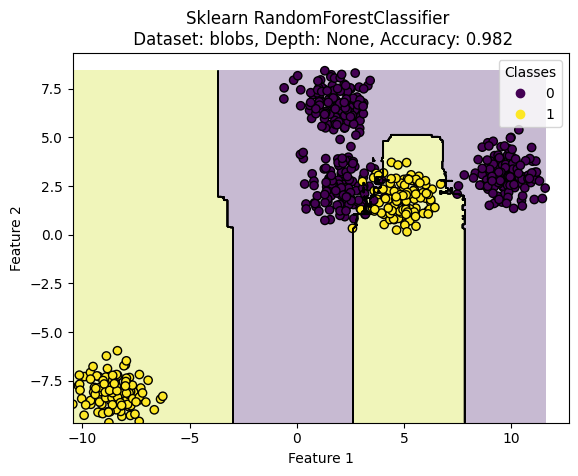

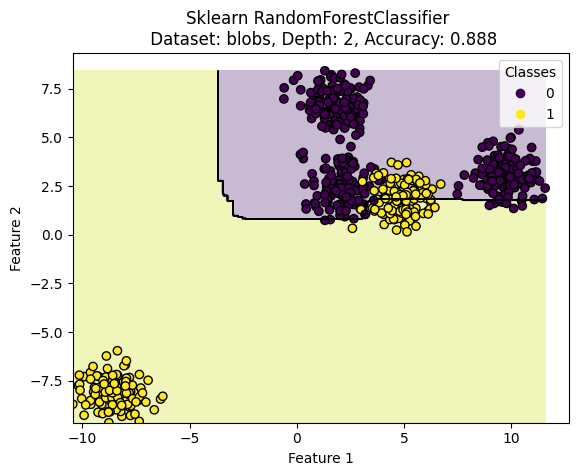

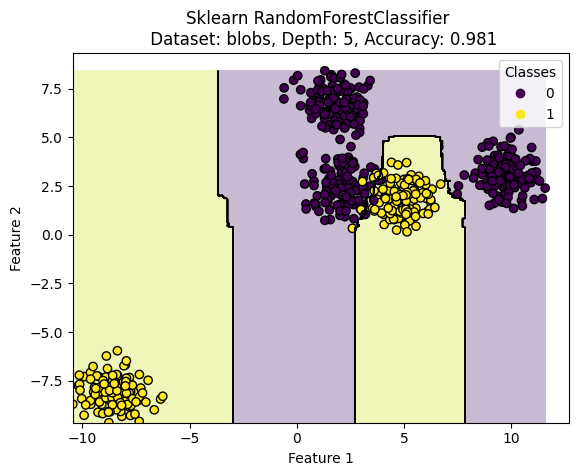

In [144]:
for res in results:
    if res['type'] != 'sklearn':
        continue
    ds_name = res['dataset']
    depth = res['depth']
    model = res['model']
    acc = res['accuracy']
    _, _, X_te, y_te = datasets[ds_name]
    title = f"Sklearn RandomForestClassifier \n Dataset: {ds_name}, Depth: {depth}, Accuracy: {acc:.3f}"
    plot_decision_boundary(X_te, y_te, model, title=title)

# Evaluation

In [150]:
pd.DataFrame(results).drop(columns=['y_pred','y_score', 'y_true', 'model']).sort_values(by=['accuracy'], ascending=False)

,type,dataset,accuracy,depth
2,implemented,moons,0.998403,NaN
9,sklearn,moons,0.998403,NaN
7,sklearn,classification,0.995208,NaN
0,implemented,classification,0.993610,NaN
1,implemented,classification,0.992013,2.0
8,sklearn,classification,0.992013,2.0
11,sklearn,blobs,0.982428,NaN
4,implemented,blobs,0.980831,NaN
6,implemented,blobs,0.980831,5.0
13,sklearn,blobs,0.980831,5.0


In [147]:
times = []

for row in results:
    ds_name = row['dataset']
    model = row['model']
    
    X_tr, y_tr = datasets[ds_name][0:2]
    
    iterations = 5
    t0 = time.time()
    for _ in range(iterations):
        model.fit(X_tr, y_tr)
    t1 = time.time() - t0
    
    times.append({
        'type': row['type'],
        'dataset': ds_name,
        'depth': row['depth'],
        'time': t1/iterations,
    }) 

In [149]:
times_df = pd.DataFrame(times)
times_df.sort_values(by=['time'], ascending=False)

,type,dataset,depth,time
2,implemented,moons,NaN,8.533486
4,implemented,blobs,NaN,6.980228
0,implemented,classification,NaN,3.913612
6,implemented,blobs,5.0,1.391400
3,implemented,moons,2.0,0.655142
1,implemented,classification,2.0,0.641267
5,implemented,blobs,2.0,0.229124
7,sklearn,classification,NaN,0.220014
11,sklearn,blobs,NaN,0.196397
9,sklearn,moons,NaN,0.193962


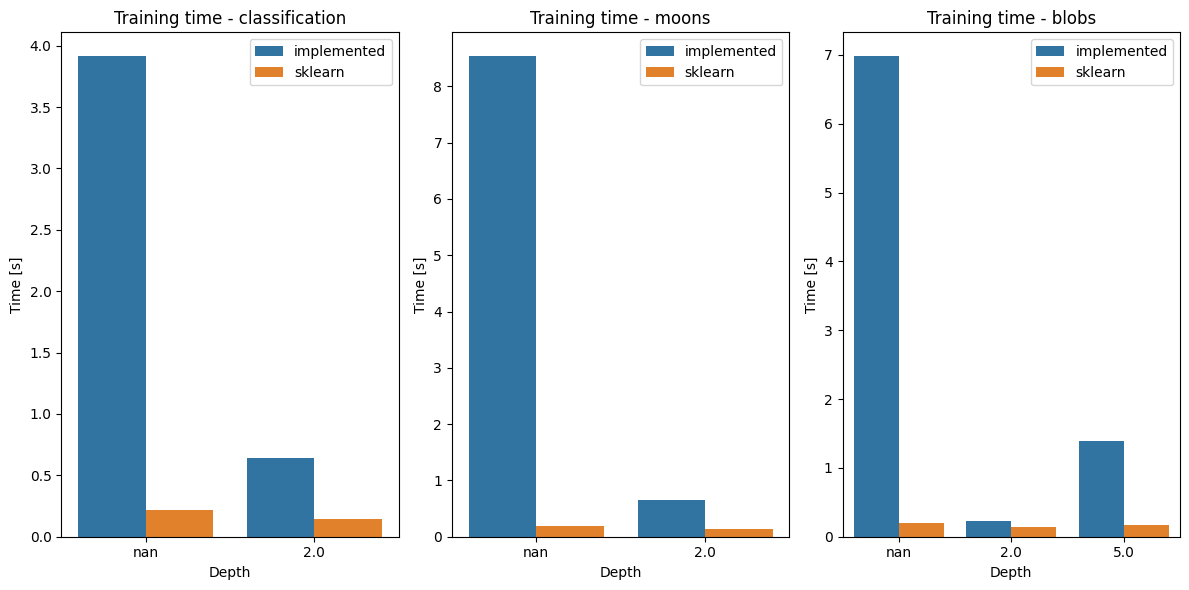

In [151]:
plt.figure(figsize=(12, 6))
for ds_name in sorted(times_df['dataset'].unique()):
    plt.subplot(1, 3, list(times_df['dataset'].unique()).index(ds_name) + 1)
    
    ds_times = times_df[times_df['dataset'] == ds_name]
    
    plot_data = ds_times.copy()
    plot_data['depth'] = plot_data['depth'].apply(lambda x: str(x))
    
    sns.barplot(x='depth', y='time', hue='type', data=plot_data)
    
    plt.title(f'Training time - {ds_name}')
    plt.xlabel('Depth')
    plt.ylabel('Time [s]')
    plt.legend()
    
plt.tight_layout()
plt.show()

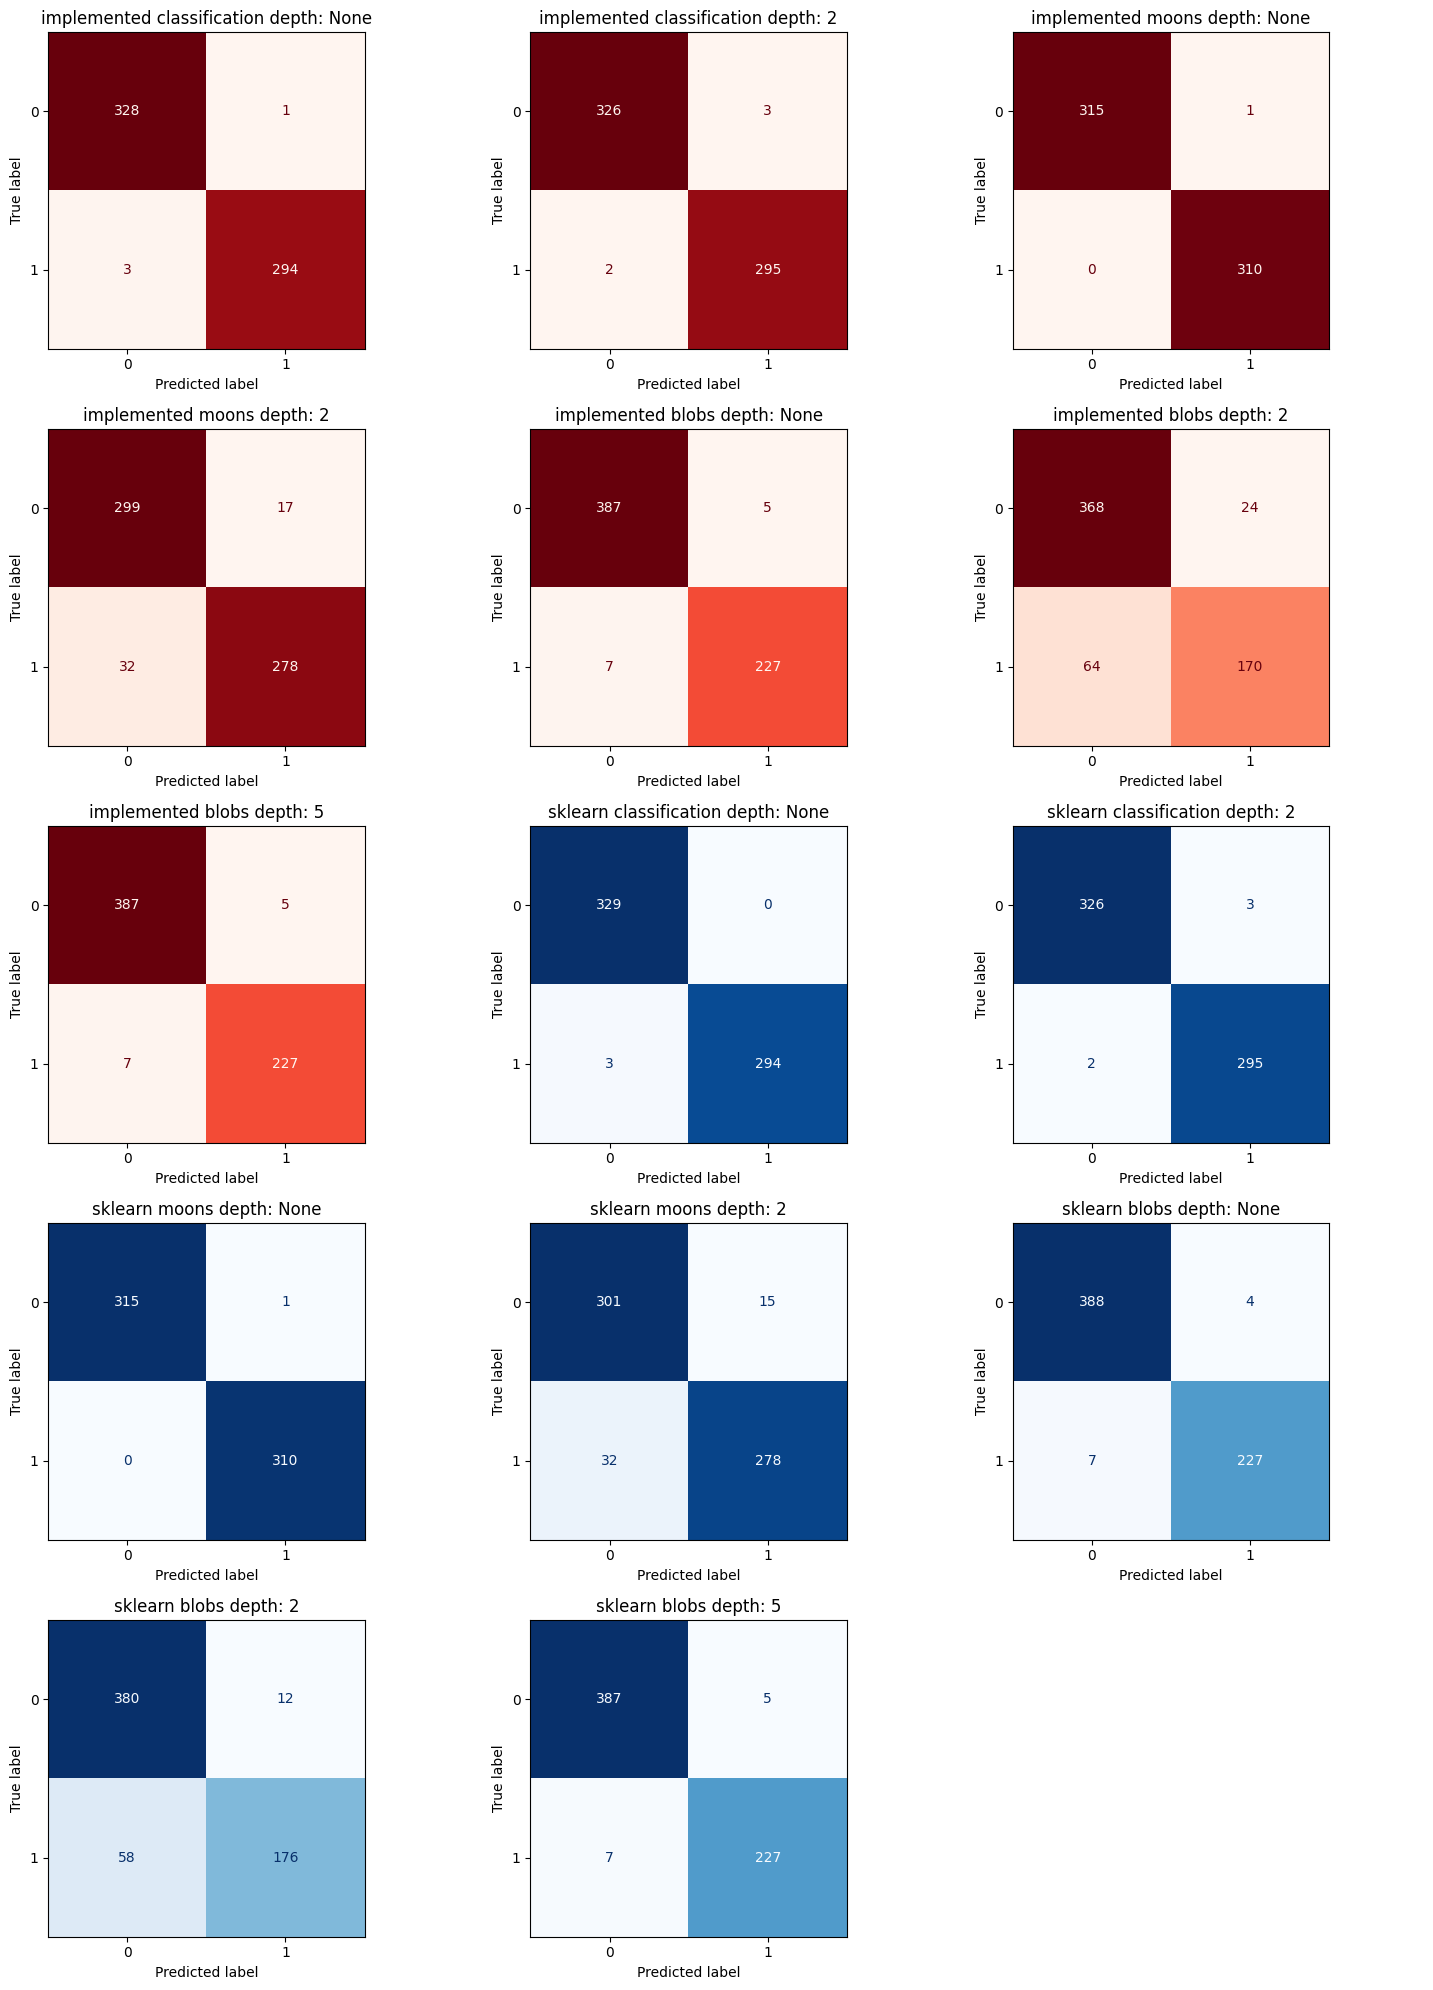

In [152]:
cms = {}
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.flatten()
for i, row in enumerate(results):
    if row['type'] == "sklearn":
        color_map = "Blues"
    else:
        color_map = "Reds"
    cm = confusion_matrix(row['y_true'], row['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[i], cmap=color_map, colorbar=False)
    cm_title = f"{row['type']} {row['dataset']} depth: {str(row['depth'])}"
    axes[i].set_title(cm_title)
    cms[cm_title] = cm

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [153]:
stats_df = pd.DataFrame(columns=['dataset', 'type', 'depth', 'specificity', 'sensitivity'])

for cm_name, cm_matrix in cms.items():
    parts = cm_name.split()
    model_type = parts[0] 
    dataset = parts[1]
    depth = parts[3]
    
    tn, fp, fn, tp = cm_matrix.ravel()
    specificity = tn / (tn+fp) if (tn+fp) > 0 else 0
    sensitivity = tp / (tp+fn) if (tp+fn) > 0 else 0

    stats_df.loc[len(stats_df)] = [model_type, dataset, depth, specificity, sensitivity]
    
stats_df = stats_df.round(3)
stats_df

,dataset,type,depth,specificity,sensitivity
0,implemented,classification,None,0.997,0.990
1,implemented,classification,2,0.991,0.993
2,implemented,moons,None,0.997,1.000
3,implemented,moons,2,0.946,0.897
4,implemented,blobs,None,0.987,0.970
5,implemented,blobs,2,0.939,0.726
6,implemented,blobs,5,0.987,0.970
7,sklearn,classification,None,1.000,0.990
8,sklearn,classification,2,0.991,0.993
9,sklearn,moons,None,0.997,1.000


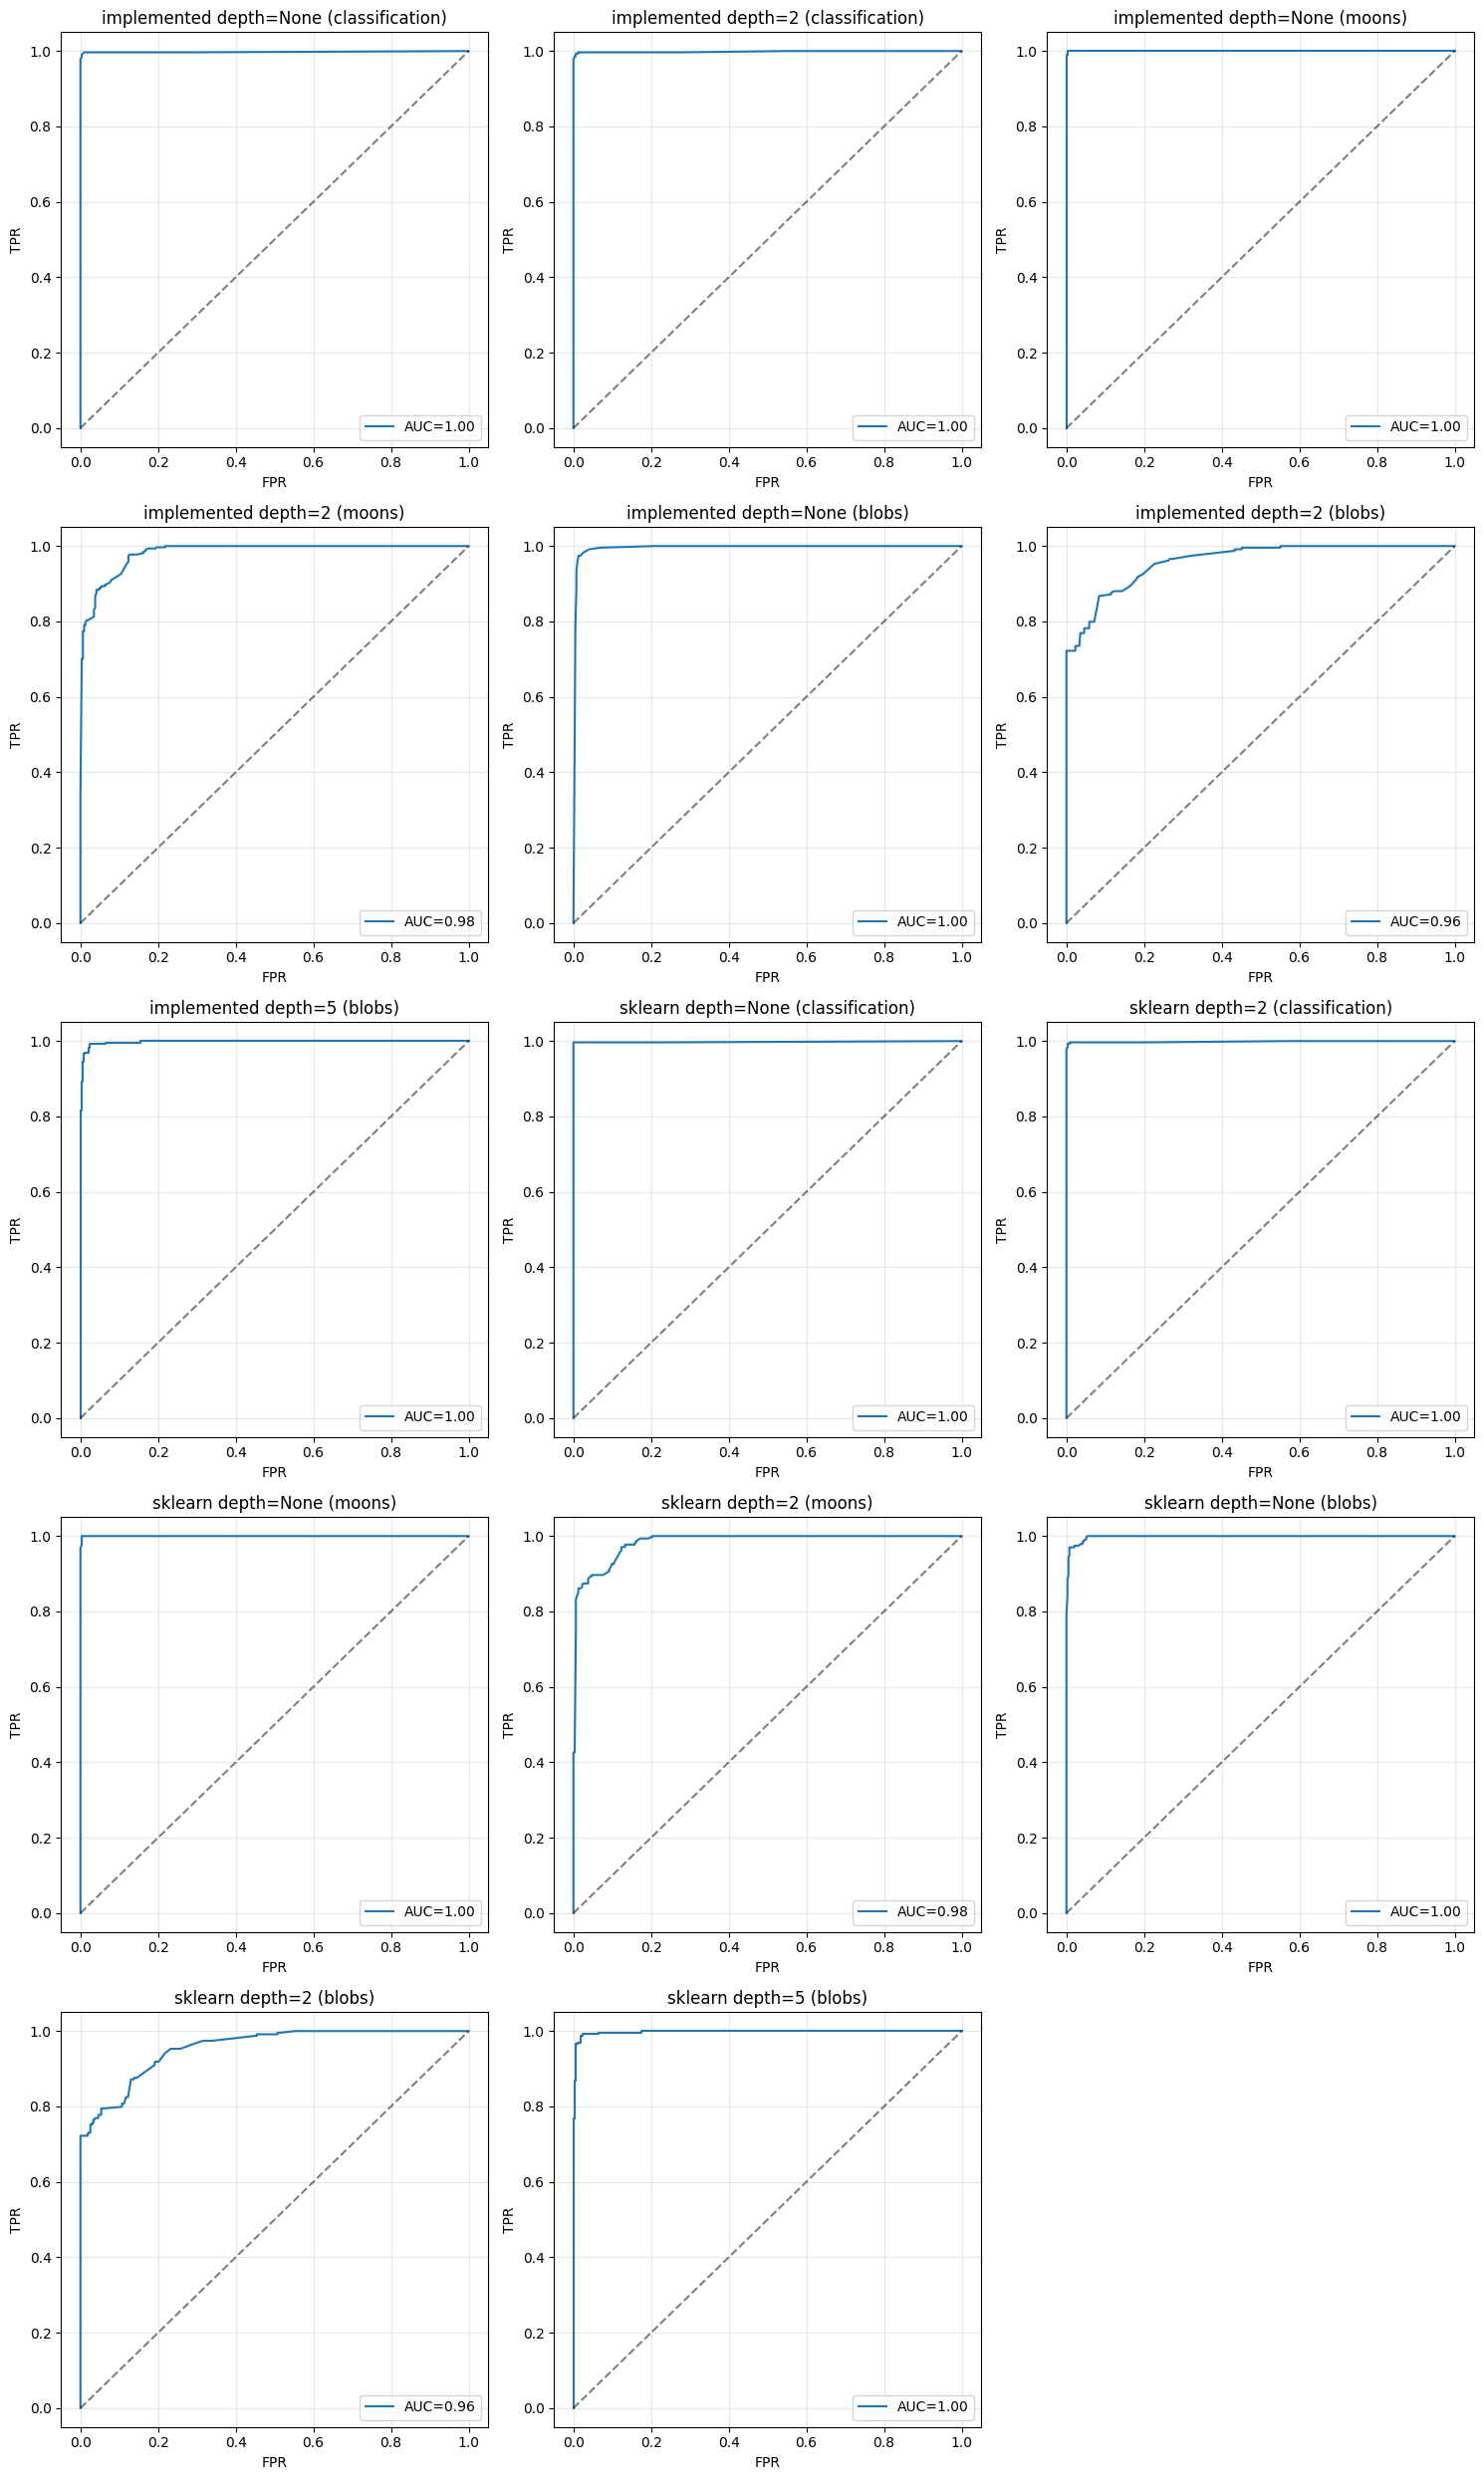

In [154]:
n_plots = len(results)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, row in enumerate(results):
    if i >= len(axes):
        break
        
    model_type = row['type']
    depth = row['depth']
    dataset = row['dataset']
    y_true = row['y_true']
    y_score = row['y_score'][:,1]
    
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    axes[i].plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
    axes[i].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[i].set_title(f"{model_type} depth={depth} ({dataset})")
    axes[i].set_xlabel("FPR")
    axes[i].set_ylabel("TPR")
    axes[i].legend(loc="lower right")
    axes[i].grid(alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# NASA JPL Asteroid Dataset

In [32]:
data = pd.read_csv('./data/dataset.csv')
data

C:\Users\bilbo\AppData\Local\Temp\ipykernel_8676\2495350115.py:1: DtypeWarning: Columns (3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('./data/dataset.csv')


,id,spkid,full_name,pdes,name,prefix,neo,pha,H,diameter,...,sigma_i,sigma_om,sigma_w,sigma_ma,sigma_ad,sigma_n,sigma_tp,sigma_per,class,rms
0,a0000001,2000001,1 Ceres,1,Ceres,NaN,N,N,3.400,939.400,...,4.608900e-09,6.168800e-08,6.624800e-08,7.820700e-09,1.111300e-11,1.196500e-12,3.782900e-08,9.415900e-09,MBA,0.43301
1,a0000002,2000002,2 Pallas,2,Pallas,NaN,N,N,4.200,545.000,...,3.469400e-06,6.272400e-06,9.128200e-06,8.859100e-06,4.961300e-09,4.653600e-10,4.078700e-05,3.680700e-06,MBA,0.35936
2,a0000003,2000003,3 Juno,3,Juno,NaN,N,N,5.330,246.596,...,3.223100e-06,1.664600e-05,1.772100e-05,8.110400e-06,4.363900e-09,4.413400e-10,3.528800e-05,3.107200e-06,MBA,0.33848
3,a0000004,2000004,4 Vesta,4,Vesta,NaN,N,N,3.000,525.400,...,2.170600e-07,3.880800e-07,1.789300e-07,1.206800e-06,1.648600e-09,2.612500e-10,4.103700e-06,1.274900e-06,MBA,0.39980
4,a0000005,2000005,5 Astraea,5,Astraea,NaN,N,N,6.900,106.699,...,2.740800e-06,2.894900e-05,2.984200e-05,8.303800e-06,4.729000e-09,5.522700e-10,3.474300e-05,3.490500e-06,MBA,0.52191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958519,bPLS6013,3246801,(6013 P-L),6013 P-L,NaN,NaN,N,N,17.135,NaN,...,6.969000e+00,7.433000e+00,4.631100e+01,2.738300e+01,1.041200e+00,1.652100e-01,1.309700e+02,7.264900e+02,MBA,0.23839
958520,bPLS6331,3246834,(6331 P-L),6331 P-L,NaN,NaN,N,N,18.500,NaN,...,1.563500e-05,5.598600e-05,2.380400e-04,1.298200e-04,2.418900e-08,3.346100e-09,4.690200e-04,1.578500e-05,MBA,0.53633
958521,bPLS6344,3013075,(6344 P-L),6344 P-L,NaN,NaN,Y,Y,20.400,NaN,...,1.853300e-05,5.691700e-05,8.969200e-05,5.272600e-05,1.650100e-07,1.101600e-08,2.830600e-04,9.127500e-05,APO,0.51556
958522,bT2S2060,3246457,(2060 T-2),2060 T-2,NaN,NaN,N,N,18.071,NaN,...,5.448800e-01,4.391600e+00,1.898800e+01,1.083800e+01,7.171600e-01,1.016700e-01,3.898400e+01,5.035500e+02,MBA,0.25641


In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("sakhawat18/asteroid-dataset")

# print("Path to dataset files:", path)

In [33]:
data = data.drop(columns=['id', 'spkid','full_name', 'name'])

In [34]:
data = data.replace(['nan', 'NaN'], np.nan)
data.isna().sum()

pdes                   0
prefix            958506
neo                    4
pha                19921
H                   6263
diameter          822315
albedo            823421
diameter_sigma    822443
orbit_id               0
epoch                  0
epoch_mjd              0
epoch_cal              0
equinox                0
e                      0
a                      0
q                      0
i                      0
om                     0
w                      0
ma                     1
ad                     4
n                      0
tp                     0
tp_cal                 0
per                    4
per_y                  1
moid               19921
moid_ld              127
sigma_e            19922
sigma_a            19922
sigma_q            19922
sigma_i            19922
sigma_om           19922
sigma_w            19922
sigma_ma           19922
sigma_ad           19926
sigma_n            19922
sigma_tp           19922
sigma_per          19926
class                  0


In [35]:
# Convert to numeric if possible, otherwise leave as is
# Instead of pd.to_numeric(data[col], errors='ignore')

for col in data.columns:
    try:
        data[col] = pd.to_numeric(data[col])
    except Exception:
        pass

In [36]:
mask = (data.isna().sum()/data.shape[0]) < 0.3
mask

pdes               True
prefix            False
neo                True
pha                True
H                  True
diameter          False
albedo            False
diameter_sigma    False
orbit_id           True
epoch              True
epoch_mjd          True
epoch_cal          True
equinox            True
e                  True
a                  True
q                  True
i                  True
om                 True
w                  True
ma                 True
ad                 True
n                  True
tp                 True
tp_cal             True
per                True
per_y              True
moid               True
moid_ld            True
sigma_e            True
sigma_a            True
sigma_q            True
sigma_i            True
sigma_om           True
sigma_w            True
sigma_ma           True
sigma_ad           True
sigma_n            True
sigma_tp           True
sigma_per          True
class              True
rms                True
dtype: bool

In [37]:
# Remove columns with more than 30% missing values
data = data.loc[:, mask]
data.isna().sum()

pdes             0
neo              4
pha          19921
H             6263
orbit_id         0
epoch            0
epoch_mjd        0
epoch_cal        0
equinox          0
e                0
a                0
q                0
i                0
om               0
w                0
ma               1
ad               4
n                0
tp               0
tp_cal           0
per              4
per_y            1
moid         19921
moid_ld        127
sigma_e      19922
sigma_a      19922
sigma_q      19922
sigma_i      19922
sigma_om     19922
sigma_w      19922
sigma_ma     19922
sigma_ad     19926
sigma_n      19922
sigma_tp     19922
sigma_per    19926
class            0
rms              2
dtype: int64

In [38]:
X, y = data.drop(columns=['neo']), data['neo']
X.shape, y.shape

((958524, 36), (958524,))

In [39]:
y.value_counts(dropna=False)

neo
N      935625
Y       22895
NaN         4
Name: count, dtype: int64

In [40]:
mask = y.isna()
y = y[~mask]
X = X[~mask]
y.value_counts(dropna=False)

neo
N    935625
Y     22895
Name: count, dtype: int64

In [41]:
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        # Numeric column
        # print(f"Numeric {col}: {X[col].iloc[-1]}")
        pass
    else:
        # Categorical column (object, string, category, etc.)
        # print(f"Categorical {col}: {X[col].iloc[-1]}")
        print(f"{col}: {X[col].nunique()}\n")

pdes: 958520

pha: 2

orbit_id: 4690

equinox: 1

class: 12



We can see that column **pdes** has the number of unique values almost the same as the number of samples. It behaves like an id, therefore we can delete it.

Column **equinox** as just one unique value therefore we can also delete the whole feature.

For feature **orbit_id** we got 4690 unique values, which is still a lot.  One-hot encoding would create 4690 new columns, which is usually not practical and can lead to overfitting or memory issues.

In [42]:
X = X.drop(columns=['pdes', 'equinox', 'orbit_id'])

In [43]:
# Fill missing values
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        # Numeric column (int, float)
        X.loc[:,col] = X[col].fillna(X[col].mean())
    else:
        # Categorical column (object, string, category, etc.)
        X.loc[:,col] = X[col].fillna(X[col].mode()[0])
        X[col] = X[col].astype(str)

In [44]:
X.isna().sum().sum()

0

In [46]:
cols_to_encode = []
for col in X.columns:
    if not pd.api.types.is_numeric_dtype(X[col]):
        cols_to_encode.append(col)
        print(X[col].value_counts(), "\n")

pha
N    956454
Y      2066
Name: count, dtype: int64 

class
MBA    855954
OMB     28355
IMB     20360
MCA     18685
APO     12687
AMO      8457
TJN      8221
TNO      3468
ATE      1729
CEN       506
AST        76
IEO        22
Name: count, dtype: int64 



In [51]:
enc = OneHotEncoder(handle_unknown='error', sparse_output = False).set_output(transform='pandas')
enc_transformed = enc.fit_transform(X[cols_to_encode])
enc_transformed

,pha_N,pha_Y,class_AMO,class_APO,class_AST,class_ATE,class_CEN,class_IEO,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958519,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
958520,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
958521,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
958522,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [53]:
X = X.drop(columns=cols_to_encode).join(enc_transformed)

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=295202, stratify=y)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((718890, 45), (718890,), (239630, 45), (239630,))

In [67]:
X_small, _, y_small, _ = train_test_split(X_train, y_train, train_size=0.1, stratify=y_train, random_state=259202)
X_small.shape, y_small.shape

((71889, 45), (71889,))

In [68]:
parameters = {
    'criterion': ('gini', 'entropy', 'log_loss'),
    'n_estimators': [10, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10],
}

clf = RandomForestClassifier()
grid_search = GridSearchCV(clf, parameters, cv=3, n_jobs=-1, verbose=5)
grid_search.fit(X_small, y_small)

Fitting 3 folds for each of 243 candidates, totalling 729 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ('gini', 'entropy', 'log_loss'),
                         'max_depth': [None, 5, 10],
                         'min_samples_leaf': [1, 5, 10],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [10, 100, 200]},
             verbose=5)

In [69]:
grid_search_df = pd.DataFrame(grid_search.cv_results_)
grid_search_df.sort_values(by=['rank_test_score'])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
217,27.002368,1.705215,0.334787,0.046684,log_loss,10,1,2,100,"{'criterion': 'log_loss', 'max_depth': 10, 'mi...",1.000000,0.999958,1.000000,0.999986,0.000020,1
142,28.352230,0.973049,0.316169,0.038176,entropy,10,1,10,100,"{'criterion': 'entropy', 'max_depth': 10, 'min...",1.000000,0.999958,1.000000,0.999986,0.000020,1
47,59.766860,0.626182,0.517929,0.052552,gini,5,10,2,200,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",1.000000,0.999958,1.000000,0.999986,0.000020,1
90,2.398599,0.475493,0.155812,0.027881,entropy,None,5,2,10,"{'criterion': 'entropy', 'max_depth': None, 'm...",1.000000,0.999958,1.000000,0.999986,0.000020,1
143,50.335578,3.020527,0.465314,0.079010,entropy,10,1,10,200,"{'criterion': 'entropy', 'max_depth': 10, 'min...",1.000000,0.999958,1.000000,0.999986,0.000020,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,2.827529,0.300553,0.174206,0.009267,gini,5,1,10,10,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.999791,0.999917,0.999958,0.999889,0.000071,238
102,3.222987,0.120044,0.197686,0.013720,entropy,None,10,5,10,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.999917,0.999708,0.999958,0.999861,0.000110,240
234,3.046036,0.229780,0.178619,0.026977,log_loss,10,10,2,10,"{'criterion': 'log_loss', 'max_depth': 10, 'mi...",0.999958,0.999708,0.999917,0.999861,0.000110,240
144,2.946484,0.441020,0.201371,0.012978,entropy,10,5,2,10,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.999917,0.999750,0.999875,0.999847,0.000071,242


In [83]:
# best params
best_params_neo = grid_search_df.sort_values(by=['rank_test_score']).iloc[0]['params']
best_params_neo

{'criterion': 'log_loss',
 'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [87]:
clf_neo = RandomForestClassifier(
    criterion = best_params_neo['criterion'],
    max_depth = best_params_neo['max_depth'],
    min_samples_leaf = best_params_neo['min_samples_leaf'],
    min_samples_split = best_params_neo['min_samples_split'],
    random_state = 259202
)
clf_neo.fit(X_train, y_train)
y_pred_neo = clf_neo.predict(X_test)
acc = accuracy_score(y_test, y_pred_neo)

In [88]:
print(f"Accuracy: {acc}")

Accuracy: 1.0


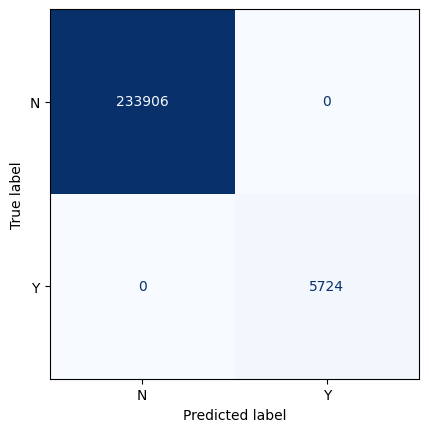

In [93]:
cm = confusion_matrix(y_test, y_pred_neo)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_neo.classes_)
disp.plot(cmap = "Blues", colorbar=False)
plt.show()

Now same process but for PHA.

In [94]:
X, y = data.drop(columns=['pha']), data['pha']
X.shape, y.shape

((958524, 36), (958524,))

In [95]:
y.value_counts(dropna=False)

pha
N      936537
NaN     19921
Y        2066
Name: count, dtype: int64

In [96]:
mask = y.isna()
y = y[~mask]
X = X[~mask]
y.value_counts(dropna=False)

pha
N    936537
Y      2066
Name: count, dtype: int64

In [97]:
for col in X.columns:
    if not pd.api.types.is_numeric_dtype(X[col]):
        print(f"{col}: {X[col].nunique()}\n")

pdes: 938603

neo: 2

orbit_id: 526

equinox: 1

class: 13



In [98]:
X = X.drop(columns=['pdes', 'equinox', 'orbit_id'])

In [101]:
X.isna().sum().sum()

6296

In [102]:
# Fill missing values
for col in X.columns:
    if pd.api.types.is_numeric_dtype(X[col]):
        # Numeric column (int, float)
        X.loc[:,col] = X[col].fillna(X[col].mean())
    else:
        # Categorical column (object, string, category, etc.)
        X.loc[:,col] = X[col].fillna(X[col].mode()[0])
        X[col] = X[col].astype(str)

In [103]:
X.isna().sum().sum()

0

In [104]:
cols_to_encode = []
for col in X.columns:
    if not pd.api.types.is_numeric_dtype(X[col]):
        cols_to_encode.append(col)
        print(X[col].value_counts(), "\n")

neo
N    915709
Y     22894
Name: count, dtype: int64 

class
MBA    837430
OMB     27815
IMB     19903
MCA     18356
APO     12687
AMO      8456
TJN      8160
TNO      3462
ATE      1729
CEN       504
AST        75
IEO        22
HYA         4
Name: count, dtype: int64 



In [105]:
enc = OneHotEncoder(handle_unknown='error', sparse_output = False).set_output(transform='pandas')
enc_transformed = enc.fit_transform(X[cols_to_encode])
enc_transformed

,neo_N,neo_Y,class_AMO,class_APO,class_AST,class_ATE,class_CEN,class_HYA,class_IEO,class_IMB,class_MBA,class_MCA,class_OMB,class_TJN,class_TNO
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958519,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
958520,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
958521,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
958522,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [106]:
X = X.drop(columns=cols_to_encode).join(enc_transformed)

In [107]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=295202, stratify=y)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((703952, 46), (703952,), (234651, 46), (234651,))

In [108]:
X_small, _, y_small, _ = train_test_split(X_train, y_train, train_size=0.1, stratify=y_train, random_state=259202)
X_small.shape, y_small.shape

((70395, 46), (70395,))

In [109]:
parameters = {
    'criterion': ('gini', 'entropy', 'log_loss'),
    'n_estimators': [10, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10],
}

clf = RandomForestClassifier()
grid_search = GridSearchCV(clf, parameters, cv=3, n_jobs=-1, verbose=5)
grid_search.fit(X_small, y_small)

Fitting 3 folds for each of 243 candidates, totalling 729 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ('gini', 'entropy', 'log_loss'),
                         'max_depth': [None, 5, 10],
                         'min_samples_leaf': [1, 5, 10],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [10, 100, 200]},
             verbose=5)

In [110]:
grid_search_df = pd.DataFrame(grid_search.cv_results_)
grid_search_df.sort_values(by=['rank_test_score'])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_leaf,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
58,21.901563,1.046201,0.387105,0.082073,gini,10,1,5,100,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.999659,0.999659,0.999744,0.999687,0.000040,1
123,2.006546,0.507404,0.182986,0.012200,entropy,5,5,10,10,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.999702,0.999446,0.999830,0.999659,0.000159,2
169,18.805128,1.183786,0.352234,0.073130,log_loss,None,1,10,100,"{'criterion': 'log_loss', 'max_depth': None, '...",0.999659,0.999659,0.999659,0.999659,0.000000,3
218,47.046566,1.313723,0.654136,0.215596,log_loss,10,1,2,200,"{'criterion': 'log_loss', 'max_depth': 10, 'mi...",0.999616,0.999659,0.999659,0.999645,0.000020,4
220,22.293861,1.332954,0.391030,0.027763,log_loss,10,1,5,100,"{'criterion': 'log_loss', 'max_depth': 10, 'mi...",0.999531,0.999659,0.999702,0.999631,0.000072,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36,3.566817,0.098070,0.285130,0.081852,gini,5,5,2,10,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.998679,0.999276,0.999190,0.999048,0.000263,238
51,3.226691,0.536756,0.213630,0.099749,gini,5,10,10,10,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.998892,0.998764,0.999361,0.999006,0.000256,240
78,2.366904,0.382244,0.197315,0.037565,gini,10,10,10,10,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.998679,0.999148,0.999105,0.998977,0.000212,241
129,2.229514,0.246340,0.223972,0.011279,entropy,5,10,5,10,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.998935,0.998935,0.998977,0.998949,0.000020,242


In [111]:
# best params
best_params_pha = grid_search_df.sort_values(by=['rank_test_score']).iloc[0]['params']
best_params_pha

{'criterion': 'gini',
 'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}

In [112]:
clf_pha = RandomForestClassifier(
    criterion = best_params_pha['criterion'],
    max_depth = best_params_pha['max_depth'],
    min_samples_leaf = best_params_pha['min_samples_leaf'],
    min_samples_split = best_params_pha['min_samples_split'],
    random_state = 259202
)
clf_pha.fit(X_train, y_train)
y_pred_pha = clf_pha.predict(X_test)
acc = accuracy_score(y_test, y_pred_pha)

In [113]:
print(f"Accuracy: {acc}")

Accuracy: 0.9999318136296032


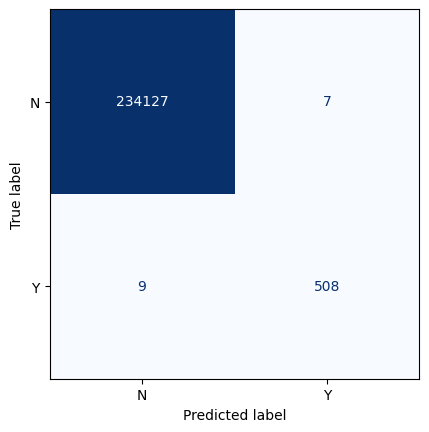

In [114]:
cm = confusion_matrix(y_test, y_pred_pha)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_pha.classes_)
disp.plot(cmap = "Blues", colorbar=False)
plt.show()

In [116]:
print(f"NEO\n{best_params_neo}")
print(f"PH\n{best_params_pha}")

NEO
{'criterion': 'log_loss', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
PH
{'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


The parameters are not the same.